## Apache Airflow

# D440_AirFlowIntroduction

**Apache Airflow is an open-source platform for building, scheduling and monitoring batch workflows.**

- A workflow connects tasks in the order required to produce a result.
- A batch run processes a bounded set of inputs and has a start and an end.
- Airflow records each run, dispatches tasks and exposes their progress in a UI.
- A daily MovieLens pipeline will connect the concepts throughout this lesson.

**Route:** purpose → big data → DAGs → architecture → job execution → recovery.

Course environment: **Airflow 3.3.1**. The supplied architecture references use classic Airflow terminology.

[What is Airflow?](https://airflow.apache.org/docs/apache-airflow/3.3.1/index.html)


## The problem Airflow solves

Start with a weather dashboard:

```text
Fetch forecast → Clean forecast data → Update dashboard
```

Each box becomes a task. An arrow says which task must finish before the next can start.

The same pattern scales to our MovieLens report:

```text
Receive files → Validate data → Run Spark → Load summary → Publish report
```

- Spark must wait until the input checks succeed.
- A temporary service failure should allow a retry.
- An operator needs to identify the failed step and read its log.
- Yesterday's input may need to be processed again after a correction.

**Airflow represents this sequence as a workflow with explicit dependencies and run history.**

[DAG concepts](https://airflow.apache.org/docs/apache-airflow/2.10.5/core-concepts/dags.html)


## Core functionalities

| Capability | Practical use |
|---|---|
| Scheduling | Start hourly, daily, manually or after a data asset update |
| Dependencies | Release a task when its upstream conditions are met |
| Operators and providers | Run Python, Bash, SQL and external service jobs |
| Retries and timeouts | Handle temporary failures and limit execution time |
| Parallel execution | Run independent checks together |
| Monitoring | Inspect task states, logs and run history |
| Backfills | Process selected historical intervals |

**Workflows as code:** Python definitions support version control, reusable functions and generated task structures. Jinja templates fill supported operator fields with run-specific values such as an input date.

[Workflows as code](https://airflow.apache.org/docs/apache-airflow/3.3.1/index.html#workflows-as-code)

[DAGs](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/dags.html) · [Tasks](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/tasks.html)


## Airflow in a big data platform

```text
Airflow task        External system doing the work
-------------       -----------------------------------
Check input    →    S3 / HDFS: files and partitions
Submit job     →    Spark on YARN / EMR: transformations
Load summary   →    Hive / warehouse: analytical tables
Validate result→    SQL engine: counts and quality rules
```

Airflow coordinates the pipeline. Spark or MapReduce distributes the large computation across a cluster.

For MovieLens, an Airflow task can submit a Spark job that joins movies and ratings, computes aggregates and writes a summary partition.

**Airflow workers and Spark executors have different responsibilities.**

Airflow is suited to bounded jobs, including jobs triggered by asset updates or events. A continuously running stream processor handles incoming records; Airflow can coordinate related batch jobs and maintenance workflows.

[Batch workflows](https://airflow.apache.org/docs/apache-airflow/3.3.1/index.html#why-airflow)

[Workloads](https://airflow.apache.org/docs/apache-airflow/2.10.5/core-concepts/overview.html#workloads)


## What is a DAG?

**DAG = Directed Acyclic Graph.**

- **Directed:** each dependency has a direction: `extract → transform`.
- **Acyclic:** following dependencies cannot lead back to the same task.
- **Graph:** tasks are nodes; dependencies are edges.

```text
Valid:    A → B → C
Invalid:  A → B → C → A   (cycle)
```

With ordinary completion dependencies, `B → C → B` means B waits for C while C waits for B: there is no valid execution order. **Airflow rejects a cyclic DAG definition during validation**, rather than running that graph into a deadlock.

Daily schedules and task retries repeat executions without adding backward dependency edges.

[Cycle validation implementation](https://github.com/apache/airflow/blob/3.3.1/task-sdk/src/airflow/sdk/definitions/dag.py)

[DAG structure](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/dags.html)


## DAG architecture: dependencies and parallel paths

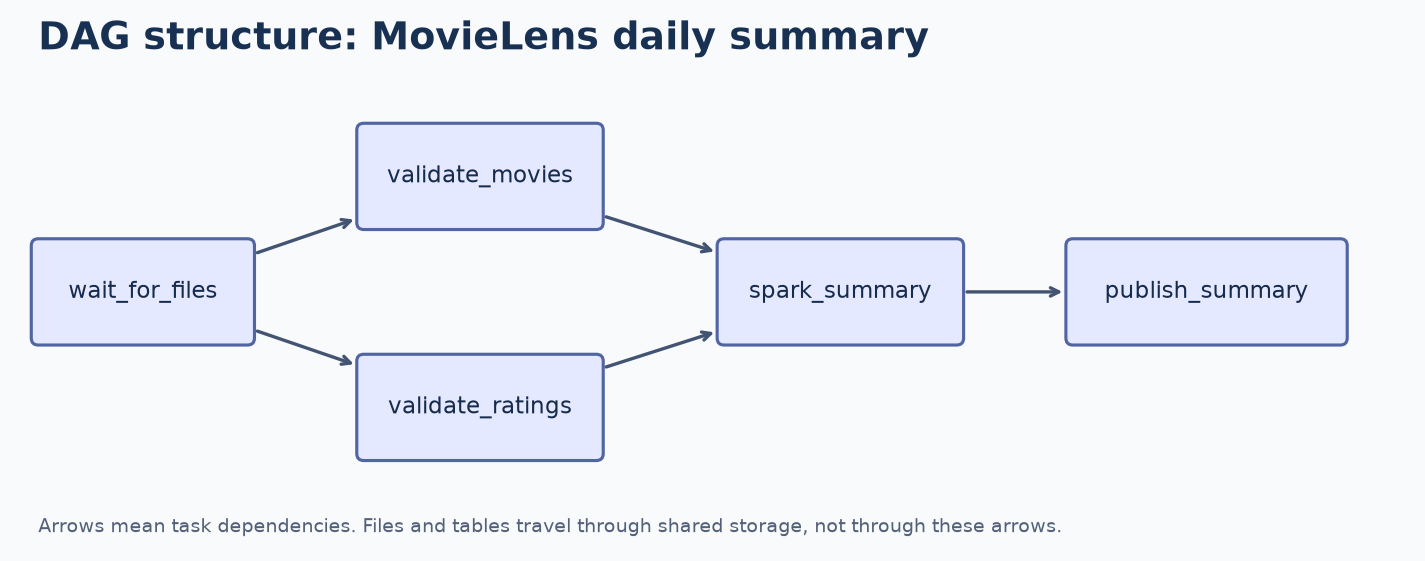

- `wait_for_files` is the root; `publish_summary` is the leaf.
- The two validation tasks can run in parallel when capacity is available.
- `spark_summary` joins the paths and requires both validations to succeed under the default `all_success` rule.
- A TaskGroup can organize related nodes visually without creating a separate DAG run.

[Dependencies and TaskGroups](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/dags.html)


## DAG, task, run and attempt

| Term | MovieLens example |
|---|---|
| DAG | `movielens_daily`: reusable workflow definition |
| Task | `validate_ratings`: one step in that definition |
| DAG run | One execution for a particular input interval |
| Task instance | `validate_ratings` within that particular run |
| Attempt | Initial execution or a retry of that task instance |

Two daily DAG runs contain separate instances of the same task. Their states can differ: one can succeed while the other fails.

An external Spark job has its own application ID. Record that ID so an Airflow task attempt can be traced to the cluster job.

[Task instances](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/tasks.html)


## Building blocks inside a DAG

| Building block | Responsibility |
|---|---|
| Operator | Defines an action, such as running a shell command |
| TaskFlow `@task` | Turns a Python function into an Airflow task |
| Sensor | Waits for a condition, such as an input file appearing |
| Hook + Connection | Accesses an external system using configured connection details |
| XCom | Shares a small value such as an output URI or job ID |
| Pool | Limits simultaneous tasks using a constrained resource |

Map actions to tasks: fetch launch metadata → download the referenced rocket pictures → notify that the download completed. Use an HTTP-capable task, a download task and a notification operator.

Store large outputs in S3, HDFS or tables and pass their locations. A local file may be unavailable to the next worker. A dependency arrow orders tasks; it does not transfer files.

[Components](https://airflow.apache.org/docs/apache-airflow/2.10.5/core-concepts/overview.html) · [XComs](https://airflow.apache.org/docs/apache-airflow/2.10.5/core-concepts/xcoms.html)


## A small DAG definition

Airflow 3 syntax; these empty tasks illustrate dependencies only.

```python
import pendulum
from airflow.sdk import DAG
from airflow.providers.standard.operators.empty import EmptyOperator

with DAG(
    dag_id="movielens_structure",
    start_date=pendulum.datetime(2026, 9, 1, tz="UTC"),
    schedule="@daily",
    catchup=False,
    default_args={"retries": 2},
) as dag:
    ready = EmptyOperator(task_id="wait_for_files")
    movies = EmptyOperator(task_id="validate_movies")
    ratings = EmptyOperator(task_id="validate_ratings")
    spark = EmptyOperator(task_id="spark_summary")
    publish = EmptyOperator(task_id="publish_summary")
    ready >> [movies, ratings] >> spark >> publish
```

`dag_id` names the workflow; `task_id` names a node; `schedule` defines its timetable; `>>` creates edges. Parsing builds the graph; workers execute it later. Replace these placeholders with real sensors and operators to process data.

[DAG definitions](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/dags.html)


## Architecture 1: classic component view

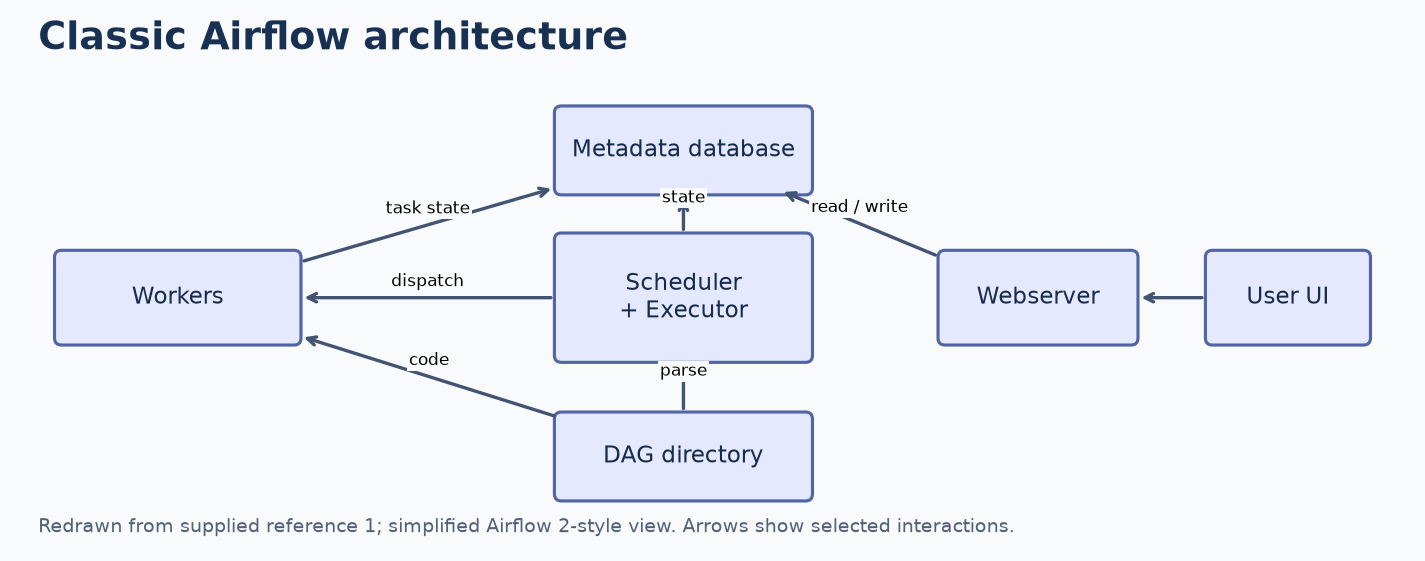

The scheduler identifies eligible tasks; its executor dispatches them. Workers perform the task actions. The webserver exposes the UI, while the metadata database records workflow state.

This redraw follows the first supplied reference. It is a **classic Airflow 2-style view**; slide 12 shows the course's Airflow 3 layout.

[Classic architecture](https://airflow.apache.org/docs/apache-airflow/2.10.5/core-concepts/overview.html)


## Architecture 2: distributed Celery workers

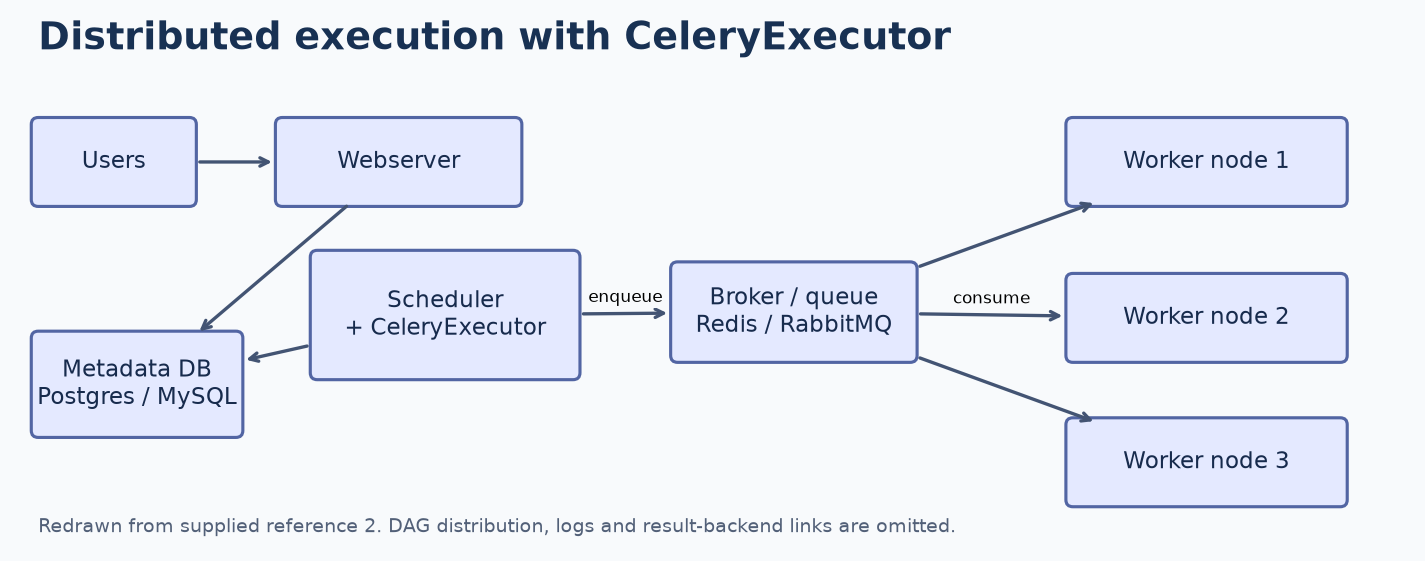

- CeleryExecutor sends task messages to a broker such as Redis or RabbitMQ.
- Available workers consume messages and execute tasks.
- The broker transports work; the configured Celery result backend tracks execution results.
- The reference's “master node” groups services for illustration; they can be deployed separately.

This is one executor architecture. LocalExecutor needs no Celery broker; KubernetesExecutor creates task pods.

[CeleryExecutor](https://airflow.apache.org/docs/apache-airflow-providers-celery/stable/celery_executor.html) · [Executors](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/executor/index.html)


## Architecture 3: the course environment

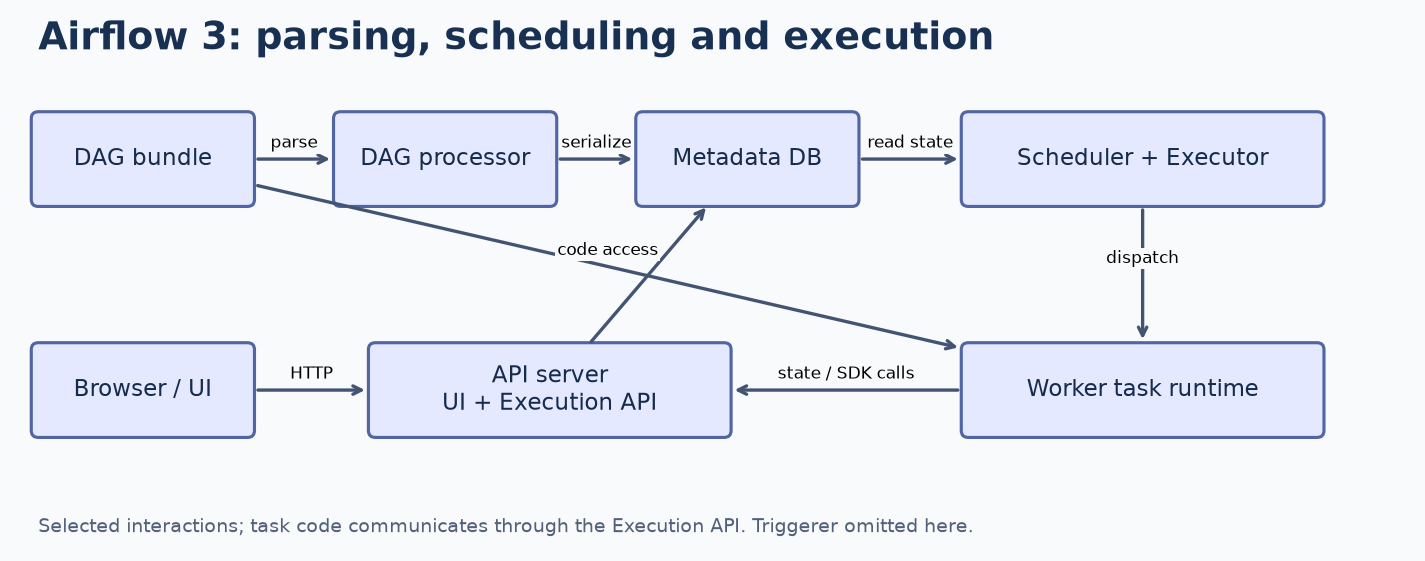

- The **DAG processor** parses workflow code and saves its serialized structure.
- The **API server** serves the UI and APIs. Task state communication uses its Execution API.
- The **scheduler and executor** choose and dispatch eligible work.
- A **DAG bundle** supplies workflow code; the default is a local folder.

The course uses LocalExecutor on one VM. These logical components still have separate roles.

[Airflow 3 architecture](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/overview.html) · [Course setup](README.md)


## Scheduling and data intervals

For a daily schedule using a data-interval timetable:

```text
Input interval:  [14 Sep 00:00 UTC ───────── 15 Sep 00:00 UTC)
Run becomes due:                           after interval closes
```

- The interval selects the data to process; actual execution may start later.
- Its logical date identifies the interval start for this schedule.
- `catchup=False` avoids automatically creating every missed historical run.
- A backfill explicitly processes a selected historical range.
- `schedule=None` creates a manually/API-triggered workflow, as in the course practicals.

Use `data_interval_start` and `data_interval_end` for partition selection rather than the worker's current date.

[Data intervals and backfill](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/dag-run.html)


## Execution step 1: discover and create a run

1. Deploy the Python DAG file into the configured DAG bundle or folder.
2. The DAG processor imports the file, discovers the DAG and serializes its definition.
3. Import or cycle errors prevent the new definition from loading. Inspect the UI or use `airflow dags list-import-errors`.
4. A schedule, asset event or manual/API trigger creates a DAG run.
5. The scheduler evaluates task instances and their dependencies within that run.

**Keep top-level Python lightweight.** Put network calls and transformations inside task execution, because DAG files are parsed repeatedly.

[Import-error CLI](https://airflow.apache.org/docs/apache-airflow/3.3.1/howto/usage-cli.html#testing-for-dag-import-errors) · [Airflow 3 architecture](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/overview.html) · [DAG authoring practices](https://airflow.apache.org/docs/apache-airflow/2.10.5/best-practices.html)


## Execution step 2: schedule and dispatch tasks

```text
Dependency conditions met
        ↓
Capacity and pool checks
        ↓
scheduled → queued → worker starts
```

- A root task has no upstream dependency to wait for.
- Other tasks must satisfy their trigger rule; the default requires upstream success.
- Pools and DAG/task concurrency settings limit eligible work.
- The executor routes the task to a local process, Celery worker or Kubernetes pod.
- Ready tasks may still wait for execution capacity.

For the MovieLens graph, both validations become eligible after file readiness succeeds.

[Executors](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/executor/index.html) · [Task lifecycle](https://airflow.apache.org/docs/apache-airflow/2.10.5/core-concepts/tasks.html)


## Execution step 3: run a big data job

Example: `spark_summary` submits a Spark application to YARN.

1. The worker starts the task runtime and prepares its execution context.
2. The operator renders interval-specific arguments and obtains connection details.
3. It submits the application; YARN allocates resources and Spark executes the computation.
4. The operator monitors completion, or a downstream sensor waits for the recorded application ID.
5. Spark writes the summary to shared storage. The task reports success only after the required completion checks pass.
6. Airflow records the outcome; downstream publication becomes eligible.

**Submission accepted is not proof of job completion.** An asynchronous submission must be followed by completion monitoring.

In Airflow 3's supervised Python execution, the task runtime communicates through a supervisor to the Execution API.

[Task execution architecture](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/overview.html#task-execution-architecture)


## Execution step 4: states, retries and waiting

```text
none → scheduled → queued → running → success
                                └──→ up_for_retry → scheduled → ...
                                └──→ failed   (no retries remain)
```

- `retries=2` permits an initial attempt plus up to two retries.
- A failed upstream task can leave dependent work `upstream_failed` under the default rule.
- Branching can mark an unselected path `skipped`.
- A rescheduling sensor uses `up_for_reschedule` between checks.
- A deferrable operator uses `deferred`; a triggerer waits asynchronously, releasing the worker slot until resumption.
- Timeouts bound task execution or waiting, according to operator configuration.

[Task states](https://airflow.apache.org/docs/apache-airflow/2.10.5/core-concepts/tasks.html) · [Deferral](https://airflow.apache.org/docs/apache-airflow/2.10.5/authoring-and-scheduling/deferring.html)


## Follow one run from start to finish

Illustrative timings for the MovieLens workflow:

| Time | Event | Consequence |
|---|---|---|
| 00:00 | Daily interval closes | Run becomes due |
| 00:01 | Input files arrive; readiness succeeds | Two validations become eligible |
| 00:02 | Both validations run | Independent paths execute together |
| 00:03 | Both validations succeed | Spark task is dispatched |
| 00:04 | Spark application starts on YARN | Airflow monitors its completion |
| 00:12 | Spark succeeds and output is verified | Publish task becomes eligible |
| 00:13 | Publish succeeds | Leaf succeeds; run can complete |

DAG-run status is evaluated from terminal leaf tasks. A successful `all_done` leaf can conceal an earlier failure, so choose completion rules carefully.

[DAG-run status](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/dag-run.html)


## Monitor, diagnose and recover

**UI path:** sign in using the deployment's configured authentication → find the DAG → choose a run → select a task instance → open its attempt log.

**Graph** shows dependencies and states for a selected run; **Grid** compares task states across runs. Trigger creates a run; unpausing allows normal scheduling.

| Observation | First checks |
|---|---|
| DAG absent | Import errors, bundle path, DAG processor |
| Run not starting | Paused state, timetable, scheduler health |
| Task waiting | Upstream states, pool slots, concurrency |
| Task queued too long | Executor and worker availability; broker if Celery |
| Spark task failed | Airflow attempt log and YARN application log |

After correcting a failure, clear the relevant task instances to rerun them. Include downstream tasks when their outputs need rebuilding.

Make writes **idempotent**: rerunning the same input produces the same intended result without duplicate rows. Use partition replacement, transactional merges or deterministic output paths. Check whether an external job is still running before resubmitting it.

[UI views](https://airflow.apache.org/docs/apache-airflow/3.3.1/index.html#dags) · [Recovery](https://airflow.apache.org/docs/apache-airflow/3.3.1/core-concepts/dag-run.html) · [Reliable tasks](https://airflow.apache.org/docs/apache-airflow/2.10.5/best-practices.html)


## Setup concepts and the practicals

The course VM already has Airflow 3.3.1. Use its existing environment and [deployment instructions](README.md).

| Setup concept | What it means in Airflow 3 |
|---|---|
| Version and constraints | A fresh install pins Airflow and uses a constraints file matching its release and supported Python minor version |
| Metadata schema | `airflow db migrate` creates or upgrades metadata tables during setup or an upgrade |
| Running services | `airflow scheduler`, `airflow dag-processor` and `airflow api-server` have separate roles |
| Login and users | Account configuration depends on the selected auth manager |

The reference PDF uses **Airflow 2.7.2 / Python 3.8**. Airflow 3 uses `airflow api-server` in place of `airflow webserver`. Its `airflow users create` command requires the FAB auth manager. Follow the course setup for operational commands.

Continue with [Bash, HDFS and MapReduce](D440_Airflow_Bash_HDFS_MapReduce.ipynb), then [MovieLens](MOVIELENS.md). Trigger a run and trace **task → worker → external job → output → next task** through its states and logs.

[Airflow 3 quick start](https://airflow.apache.org/docs/apache-airflow/3.3.1/start.html) · [Installation and constraints](https://airflow.apache.org/docs/apache-airflow/stable/installation/installing-from-pypi.html)

**Additional reference:** Shyarnis Ghising, *Getting started with Apache Airflow*, 12 December 2023, supplied as `main.pdf`. Weather and rocket examples are paraphrased from PDF pages 6–7 and 15–16. Slides 10–11 redraw the previously supplied architecture images; all four notebook diagrams remain embedded.
